In [1]:
"""
プロジェクト：
Spotify日本音楽市場データ分析

目的：
・日本ユーザーの音楽聴取傾向を把握する
・ヒット曲の特徴を分析する
・推薦アルゴリズム改善の示唆を得る
"""


'\nプロジェクト：\nSpotify日本音楽市場データ分析\n\n目的：\n・日本ユーザーの音楽聴取傾向を把握する\n・ヒット曲の特徴を分析する\n・推薦アルゴリズム改善の示唆を得る\n'

In [9]:
import pandas as pd

df = pd.read_csv("regional-jp-daily-2026-02-11.csv")
df.head()
df.info()
df.isna().sum()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   rank           200 non-null    int64 
 1   uri            200 non-null    object
 2   artist_names   200 non-null    object
 3   track_name     200 non-null    object
 4   source         200 non-null    object
 5   peak_rank      200 non-null    int64 
 6   previous_rank  200 non-null    int64 
 7   days_on_chart  200 non-null    int64 
 8   streams        200 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 14.2+ KB


,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,days_on_chart,streams
count,200.000000,200,200,200,200,200.000000,200.000000,200.000000,200.00000
unique,NaN,200,73,200,38,NaN,NaN,NaN,NaN
top,NaN,spotify:track:6kKvmT4i0Dercz6f3kftg3,back number,ただ君に晴れ,Universal Music LLC,NaN,NaN,NaN,NaN
freq,NaN,1,21,1,72,NaN,NaN,NaN,NaN
mean,100.500000,NaN,NaN,NaN,NaN,23.625000,89.115000,908.555000,110573.02000
std,57.879185,NaN,NaN,NaN,NaN,29.047256,59.154527,873.824107,69020.88333
min,1.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,1.000000,56713.00000
25%,50.750000,NaN,NaN,NaN,NaN,2.750000,37.750000,170.000000,65229.50000
50%,100.500000,NaN,NaN,NaN,NaN,10.000000,87.500000,586.500000,77618.50000
75%,150.250000,NaN,NaN,NaN,NaN,43.500000,138.250000,1561.250000,145191.00000


In [12]:
df["streams"].sum()
df["streams"].mean()
df.groupby("artist_names")["streams"].sum().sort_values(ascending=False).head(10)
total_streams = df["streams"].sum()
avg_streams = df["streams"].mean()
total_streams, avg_streams



(22114604, 110573.02)

In [17]:
df["artist_names"].value_counts().head(20)

artist_streams = df.groupby("artist_names")["streams"].sum().sort_values(ascending=False)
artist_streams.head(15)


artist_names
back number              2848890
Mrs. GREEN APPLE         2710095
HANA                     1657530
Kenshi Yonezu            1039130
Vaundy                    942653
Number_i                  752695
CHANMINA                  686950
King Gnu                  599615
sakanaction               582526
M!LK                      575054
Aimyon                    475235
OFFICIAL HIGE DANDISM     448479
BE:FIRST                  376716
Fujii Kaze                365543
Jin                       364279
Name: streams, dtype: int64

In [6]:
funnel = {
"新曲(<=30日)": len(df[df["days_on_chart"]<=30]),
"安定期(30-100)": len(df[(df["days_on_chart"]>30)&(df["days_on_chart"]<=100)]),
"人気曲(100-500)": len(df[(df["days_on_chart"]>100)&(df["days_on_chart"]<=500)]),
"長期ヒット(>500)": len(df[df["days_on_chart"]>500])
}

funnel


{'新曲(<=30日)': 16, '安定期(30-100)': 20, '人気曲(100-500)': 60, '長期ヒット(>500)': 104}

In [7]:
new = df[df["days_on_chart"]<=30]["streams"]
old = df[df["days_on_chart"]>500]["streams"]

new.mean(), old.mean()


(132903.375, 96356.00961538461)

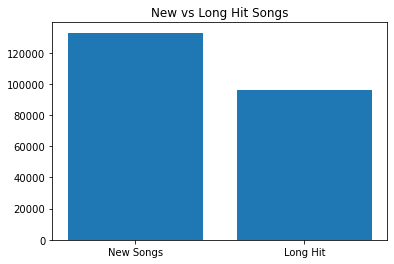

In [8]:
import matplotlib.pyplot as plt

plt.bar(["New Songs","Long Hit"],[new.mean(),old.mean()])
plt.title("New vs Long Hit Songs")
plt.show()


In [18]:
bins = [-1, 30, 100, 500, 1500, 10**9]
labels = ["New(<=30)", "Early(31-100)", "Mid(101-500)", "Long(501-1500)", "Evergreen(>1500)"]

df["lifecycle"] = pd.cut(df["days_on_chart"], bins=bins, labels=labels)
funnel_cnt = df["lifecycle"].value_counts().reindex(labels)
funnel_cnt


New(<=30)           16
Early(31-100)       20
Mid(101-500)        60
Long(501-1500)      50
Evergreen(>1500)    54
Name: lifecycle, dtype: int64

In [19]:
 funnel_ratio = (funnel_cnt / funnel_cnt.sum()).round(3)
pd.DataFrame({"count": funnel_cnt, "ratio": funnel_ratio})


,count,ratio
New(<=30),16,0.08
Early(31-100),20,0.10
Mid(101-500),60,0.30
Long(501-1500),50,0.25
Evergreen(>1500),54,0.27


In [20]:
funnel_streams = df.groupby("lifecycle")["streams"].sum().reindex(labels)
funnel_streams_ratio = (funnel_streams / funnel_streams.sum()).round(3)

pd.DataFrame({"streams_sum": funnel_streams, "streams_ratio": funnel_streams_ratio})


,streams_sum,streams_ratio
lifecycle,,
New(<=30),2126454,0.096
Early(31-100),2675445,0.121
Mid(101-500),7291680,0.330
Long(501-1500),4462252,0.202
Evergreen(>1500),5558773,0.251


In [21]:
A = df[df["days_on_chart"] <= 30]["streams"]
B = df[df["days_on_chart"] > 500]["streams"]

A.mean(), B.mean(), A.median(), B.median(), len(A), len(B)


(132903.375, 96356.00961538461, 105507.0, 74498.0, 16, 104)

In [22]:
!pip -q install scipy
from scipy import stats

t_stat, p_val = stats.ttest_ind(A, B, equal_var=False)  # Welch t-test
t_stat, p_val


(2.1607212672739897, 0.04442851827861447)

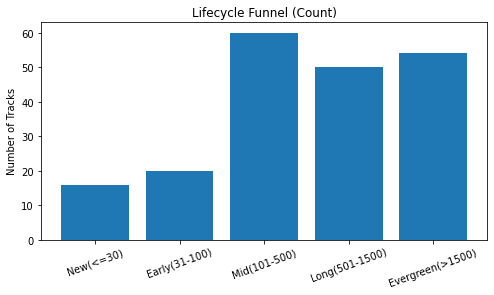

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(funnel_cnt.index, funnel_cnt.values)
plt.title("Lifecycle Funnel (Count)")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=20)
plt.show()


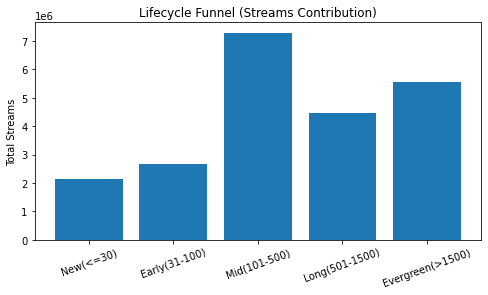

In [24]:
plt.figure(figsize=(8,4))
plt.bar(funnel_streams.index.astype(str), funnel_streams.values)
plt.title("Lifecycle Funnel (Streams Contribution)")
plt.ylabel("Total Streams")
plt.xticks(rotation=20)
plt.show()


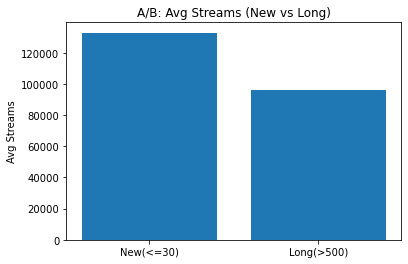

In [25]:
plt.figure(figsize=(6,4))
plt.bar(["New(<=30)", "Long(>500)"], [A.mean(), B.mean()])
plt.title("A/B: Avg Streams (New vs Long)")
plt.ylabel("Avg Streams")
plt.show()


In [26]:
pd.DataFrame({
    "count": funnel_cnt,
    "ratio": (funnel_cnt / funnel_cnt.sum()).round(3),
    "streams_sum": funnel_streams,
    "streams_ratio": (funnel_streams / funnel_streams.sum()).round(3)
})


,count,ratio,streams_sum,streams_ratio
New(<=30),16,0.08,2126454,0.096
Early(31-100),20,0.10,2675445,0.121
Mid(101-500),60,0.30,7291680,0.330
Long(501-1500),50,0.25,4462252,0.202
Evergreen(>1500),54,0.27,5558773,0.251
